# Hard coal NPV simulation

Run the hard coal electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [46]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_model import simulate_hard_coal_npv

In [47]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_hard_coal_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,annual_output_mwh,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,emissions_tco2_per_mwh_e,coal_price_eur_per_mwh_th,electricity_price_eur_per_mwh,carbon_price_eur_per_t,initial_capex_eur,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur
0,0,1000000.0,243.902439,243902.439024,1861.067935,34.001020,5.237989,2.624710,0.853931,11.315425,94.07,1.0,4.539190e+08,94070000.0,8.292932e+06,5.237989e+06,2.969971e+07,853930.747922,4.998544e+07,7.966433e+07
1,1,1000000.0,243.902439,243902.439024,1898.156289,39.176444,4.907802,2.567357,0.884836,15.132594,94.07,1.0,4.629649e+08,94070000.0,9.555230e+06,4.907802e+06,3.885078e+07,884836.162012,3.987136e+07,-3.734716e+07
2,2,1000000.0,243.902439,243902.439024,1907.676144,40.064457,4.608330,2.663969,0.885366,9.487317,94.07,1.0,4.652869e+08,94070000.0,9.771819e+06,4.608330e+06,2.527392e+07,885366.317552,5.353057e+07,1.061400e+08
3,3,1000000.0,243.902439,243902.439024,1816.875815,39.003643,4.679406,2.499085,0.849594,18.398941,94.07,1.0,4.431404e+08,94070000.0,9.513084e+06,4.679406e+06,4.598051e+07,849593.915375,3.304740e+07,-9.036683e+07
4,4,1000000.0,243.902439,243902.439024,1881.052120,32.533849,5.997071,2.597758,0.852541,21.660610,94.07,1.0,4.587932e+08,94070000.0,7.935085e+06,5.997071e+06,5.626903e+07,852541.237697,2.301628e+07,-2.130996e+08


In [48]:
npv_million_eur = results["npv_eur"] / 1_000_000

summary = npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).to_frame(
    name="NPV million EUR"
)
summary

,NPV million EUR
count,1000000.000000
mean,-53.148740
std,103.387900
min,-410.836938
5%,-237.285811
50%,-43.800929
95%,102.507077
max,222.061922


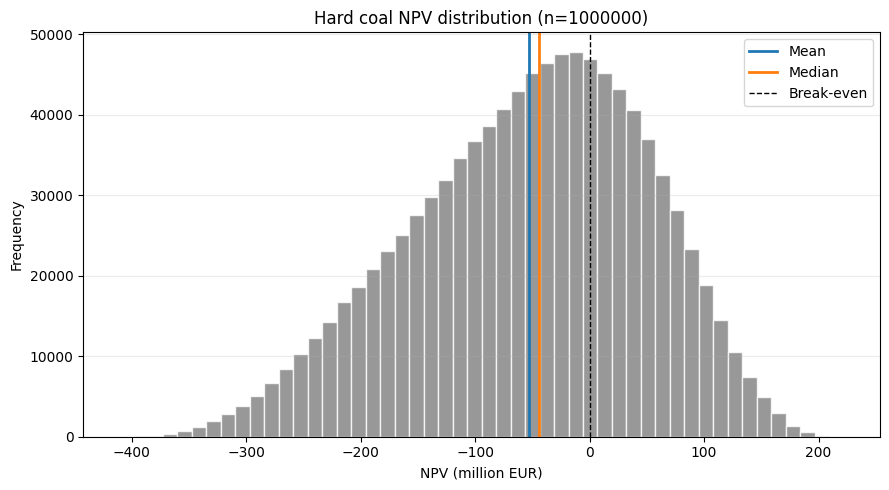

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [50]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.326128
annual_variable_opex_eur      5.166458
annual_fuel_cost_eur         37.991411
annual_emissions_cost_eur     0.873328
annual_net_cash_flow_eur     40.712676
Name: Mean annual value, million EUR, dtype: float64